# 🍺 Beer Distribution Game — RL Agent with Memory


---

## The Game

The **Beer Distribution Game** (MIT Sloan, 1960s) simulates a 4-stage supply chain:

```
FACTORY → DISTRIBUTOR → WHOLESALER → RETAILER → 👥 Customer Demand
```

Each stage can only see **its own inventory** — not the full chain.  
A small demand change at the retailer creates **massive order swings** upstream.  
This is called the **Bullwhip Effect** — and it costs the real world billions every year.

---

## What This Notebook Does

- 🏭 Simulates all 4 stages of the Beer Game supply chain
- 🤖 Trains an **RL agent** to manage the Retailer role
- 📊 Compares agent vs **human-like baseline** (fixed order rule)
- 🧠 **Memory system** tracks learning episode by episode
- 📈 Shows whether the agent **reduces the bullwhip effect**

---

## Reward System

| Event | Points |
|---|---|
| Meeting customer demand exactly | +20 |
| Partial fulfillment | proportional reward |
| Each unit of backlog (unmet demand) | −2 per unit |
| Each unit held in inventory (holding cost) | −0.5 per unit |
| Stockout (zero inventory, demand > 0) | −10 |
| Stable order (close to last order) | +2 (anti-bullwhip bonus) |


In [1]:
# CELL 1 — Install
!pip install matplotlib numpy pandas pillow -q
print('OK')

OK


In [2]:
# CELL 2 — Imports & constants
import io, time, random
from collections import defaultdict, deque

import numpy as np
import pandas as pd

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

from IPython.display import display, clear_output, Image as IPImage

# ── Simulation ────────────────────────────────────────────
N_EPISODES      = 120       # training episodes
N_WEEKS         = 36        # weeks per episode (classic beer game length)
LEAD_TIME       = 2         # weeks for orders to arrive
INIT_INVENTORY  = 12        # starting stock at each stage
INIT_ORDER      = 4         # initial order in pipeline

# ── Demand scenarios ──────────────────────────────────────
# Classic beer game: steady 4 units/week then sudden jump to 8
def generate_demand(n_weeks=N_WEEKS, seed=None):
    rng = np.random.RandomState(seed)
    demand = []
    for w in range(n_weeks):
        if w < 4:
            demand.append(4)
        elif w < 8:
            demand.append(8)   # sudden step-up — the classic trigger
        else:
            # Small random noise around 8
            demand.append(max(0, int(rng.normal(8, 1.5))))
    return demand

# ── Q-Learning ────────────────────────────────────────────
ALPHA           = 0.15
GAMMA           = 0.90
EPS_START       = 1.0
EPS_END         = 0.05
EPS_DECAY       = 0.97

# Order action space: agent picks how many units to order
MAX_ORDER       = 20
ORDER_ACTIONS   = list(range(0, MAX_ORDER + 1))  # 0..20 units

# ── Rendering ─────────────────────────────────────────────
RENDER_EVERY    = 3         # render every Nth week
WEEK_SLEEP      = 0.06
EPISODE_SLEEP   = 0.4

# Colors
C_FACTORY    = '#00c896'
C_DIST       = '#4a9eff'
C_WHOLE      = '#b8a4ff'
C_RETAIL     = '#FFD700'
C_DEMAND     = '#ff6b35'
C_BACKLOG    = '#ff4444'
C_BG         = '#0a1628'
C_GRID       = '#1e2a3a'

STAGE_COLORS = [C_FACTORY, C_DIST, C_WHOLE, C_RETAIL]
STAGE_NAMES  = ['Factory', 'Distributor', 'Wholesaler', 'Retailer']

print('Constants ready.')

Constants ready.


In [3]:
# CELL 3 — Beer Game supply chain environment
class BeerGameEnv:
    """
    4-stage Beer Distribution Game.
    Stages: 0=Factory, 1=Distributor, 2=Wholesaler, 3=Retailer

    The RL agent controls the RETAILER (stage 3).
    Stages 0-2 use a simple human-like heuristic:
      order = last_received + (target_inventory - current_inventory) * 0.5
    """

    def __init__(self, demand_seed=None):
        self.demand_seed = demand_seed
        self.reset()

    def reset(self, demand_seed=None):
        if demand_seed is not None:
            self.demand_seed = demand_seed
        self.demand_schedule = generate_demand(N_WEEKS, self.demand_seed)

        # Inventory at each stage
        self.inventory  = [INIT_INVENTORY] * 4
        # Backlog (unmet demand) at each stage
        self.backlog    = [0] * 4
        # Order pipelines: orders in transit (deque of length LEAD_TIME)
        self.pipeline   = [deque([INIT_ORDER]*LEAD_TIME, maxlen=LEAD_TIME) for _ in range(4)]
        # History for plotting
        self.inv_history    = [[] for _ in range(4)]
        self.order_history  = [[] for _ in range(4)]
        self.backlog_history= [[] for _ in range(4)]
        self.demand_history = []
        self.week = 0
        return self._get_state()

    def _get_state(self):
        """
        State visible to retailer agent:
        (inventory, backlog, incoming_order_next_week, current_demand)
        Discretised into bins for Q-table.
        """
        inv     = min(self.inventory[3], 30)   # cap at 30
        bl      = min(self.backlog[3],   20)   # cap at 20
        incoming= min(self.pipeline[3][0], 20) # what arrives next week
        demand  = self.demand_schedule[self.week] if self.week < N_WEEKS else 0

        # Bin into discrete buckets
        inv_bin  = inv  // 3   # 0..10
        bl_bin   = bl   // 2   # 0..10
        inc_bin  = incoming // 2
        dem_bin  = demand   // 2
        return (inv_bin, bl_bin, inc_bin, dem_bin)

    def _human_order(self, stage):
        """
        Heuristic used by non-agent stages (Factory, Distributor, Wholesaler).
        Mimics human over-ordering behaviour — causes the bullwhip effect.
        """
        target = 12
        inv    = self.inventory[stage]
        bl     = self.backlog[stage]
        # Humans over-react: they order extra when they feel short
        order  = max(0, (target - inv) + bl + 2)   # +2 = panic buffer
        return min(order, MAX_ORDER)

    def step(self, retailer_order):
        """
        Advance one week.
        retailer_order: integer chosen by the RL agent (0..MAX_ORDER)
        Returns: next_state, reward, done, info
        """
        assert self.week < N_WEEKS, 'Episode already finished'

        demand = self.demand_schedule[self.week]
        self.demand_history.append(demand)

        # Orders placed by each stage this week
        orders = [
            self._human_order(0),   # Factory
            self._human_order(1),   # Distributor
            self._human_order(2),   # Wholesaler
            retailer_order,         # Retailer (RL agent)
        ]

        # Receive incoming shipments (front of pipeline)
        received = [p[0] for p in self.pipeline]

        # Push new orders into pipelines
        for i in range(4):
            self.pipeline[i].append(orders[i])

        # Update inventories
        for i in range(4):
            self.inventory[i] += received[i]

        # Fulfil demand / create backlog
        # Customer demand hits retailer; each upstream stage serves the next downstream
        downstream_demand = [orders[1], orders[2], orders[3], demand]
        for i in range(4):
            total_needed = downstream_demand[i] + self.backlog[i]
            shipped      = min(self.inventory[i], total_needed)
            self.inventory[i] -= shipped
            self.backlog[i]    = max(0, total_needed - shipped)

        # Record history
        for i in range(4):
            self.inv_history[i].append(self.inventory[i])
            self.order_history[i].append(orders[i])
            self.backlog_history[i].append(self.backlog[i])

        # ── Reward (retailer perspective) ──────────────────
        ret_inv = self.inventory[3]
        ret_bl  = self.backlog[3]

        reward = 0.0
        # Holding cost
        reward -= ret_inv * 0.5
        # Backlog penalty
        reward -= ret_bl  * 2.0
        # Stockout penalty
        if ret_inv == 0 and demand > 0:
            reward -= 10.0
        # Demand met reward
        met = min(received[3] + INIT_INVENTORY if self.week == 0 else received[3], demand)
        reward += (met / max(demand, 1)) * 20.0
        # Anti-bullwhip: reward stable ordering
        if self.week > 0:
            prev_order = self.order_history[3][-2] if len(self.order_history[3]) > 1 else INIT_ORDER
            if abs(retailer_order - prev_order) <= 2:
                reward += 2.0

        self.week += 1
        done = self.week >= N_WEEKS
        return self._get_state(), reward, done, {
            'inventory': ret_inv, 'backlog': ret_bl,
            'demand': demand, 'order': retailer_order
        }

print('BeerGameEnv ready.')

BeerGameEnv ready.


In [4]:
# CELL 4 — Agent memory
class BeerAgentMemory:
    def __init__(self):
        self.episodes        = []
        self.rewards         = []
        self.total_backlogs  = []
        self.total_holdings  = []
        self.bullwhip_ratios = []   # std(orders) / std(demand) — lower is better
        self.stockout_weeks  = []
        self.best_reward     = -1e9
        self.best_orders     = None
        self.best_inventory  = None

    def record(self, ep, total_reward, order_hist, inv_hist, bl_hist, demand_hist):
        total_bl      = sum(bl_hist)
        total_holding = sum(inv_hist)
        stockouts     = sum(1 for i, b in zip(inv_hist, bl_hist) if i == 0 and b > 0)
        demand_std    = np.std(demand_hist) + 1e-9
        order_std     = np.std(order_hist)
        bullwhip      = order_std / demand_std

        self.episodes.append({
            'episode' : ep,
            'reward'  : round(total_reward, 2),
            'backlog' : total_bl,
            'holding' : total_holding,
            'bullwhip': round(bullwhip, 3),
            'stockouts': stockouts,
        })
        self.rewards.append(total_reward)
        self.total_backlogs.append(total_bl)
        self.total_holdings.append(total_holding)
        self.bullwhip_ratios.append(bullwhip)
        self.stockout_weeks.append(stockouts)

        if total_reward > self.best_reward:
            self.best_reward    = total_reward
            self.best_orders    = order_hist[:]
            self.best_inventory = inv_hist[:]

print('BeerAgentMemory ready.')

BeerAgentMemory ready.


In [5]:
# CELL 5 — Q-Learning agent
class BeerAgent:
    def __init__(self):
        self.Q       = defaultdict(lambda: np.zeros(len(ORDER_ACTIONS)))
        self.epsilon = EPS_START
        self.memory  = BeerAgentMemory()

    def act(self, state):
        if random.random() < self.epsilon:
            return random.choice(ORDER_ACTIONS)
        return ORDER_ACTIONS[int(np.argmax(self.Q[state]))]

    def learn(self, s, a, r, s2):
        ai = ORDER_ACTIONS.index(a)
        old = self.Q[s][ai]
        self.Q[s][ai] = old + ALPHA*(r + GAMMA*np.max(self.Q[s2]) - old)

    def run_episode(self, ep_num, render=False):
        """
        Run one full episode (N_WEEKS weeks).
        If render=True, yields frames for live animation.
        """
        env   = BeerGameEnv(demand_seed=ep_num % 20)
        state = env.reset(demand_seed=ep_num % 20)
        total_r = 0.0

        frames = []

        for week in range(N_WEEKS):
            action   = self.act(state)
            s2, r, done, info = env.step(action)
            self.learn(state, action, r, s2)
            total_r += r
            state    = s2

            if render:
                frames.append({
                    'week'     : week + 1,
                    'inv'      : env.inv_history,
                    'orders'   : env.order_history,
                    'backlog'  : env.backlog_history,
                    'demand'   : env.demand_history,
                    'reward'   : total_r,
                    'info'     : info,
                    'done'     : done,
                })

        self.memory.record(
            ep_num, total_r,
            env.order_history[3],
            env.inv_history[3],
            env.backlog_history[3],
            env.demand_history,
        )
        self.epsilon = max(EPS_END, self.epsilon * EPS_DECAY)

        if render:
            return total_r, env, frames
        return total_r, env

print('BeerAgent ready.')

BeerAgent ready.


In [6]:
# CELL 6 — Human baseline (pure heuristic, no learning)
class HumanBaseline:
    """
    Simulates a human player using the classic over-ordering heuristic.
    This recreates what you experienced in class — panic ordering, bullwhip.
    """
    def run_episode(self, demand_seed=0):
        env   = BeerGameEnv(demand_seed=demand_seed)
        state = env.reset(demand_seed=demand_seed)
        total_r = 0.0
        prev_inv = INIT_INVENTORY

        for week in range(N_WEEKS):
            inv    = env.inventory[3]
            bl     = env.backlog[3]
            demand = env.demand_schedule[week]
            # Human heuristic: order = demand_estimate + safety_stock_correction
            target = 14
            order  = max(0, demand + max(0, target - inv) + bl)
            order  = min(order, MAX_ORDER)
            _, r, done, _ = env.step(order)
            total_r += r
        return total_r, env

print('HumanBaseline ready.')

HumanBaseline ready.


In [7]:
# CELL 7 — Frame renderer
def make_beer_frame(week, inv_hist, order_hist, backlog_hist,
                    demand_hist, ep_num, total_reward, epsilon,
                    reward_history, bullwhip_history):
    weeks_so_far = list(range(1, week+1))

    fig = plt.figure(figsize=(16, 9))
    fig.patch.set_facecolor(C_BG)
    gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.38)

    def sax(ax, title, xl='Week', yl=''):
        ax.set_facecolor(C_BG)
        ax.set_title(title, color='white', fontsize=9, fontfamily='monospace', pad=4)
        ax.set_xlabel(xl, color='#aaa', fontsize=8)
        ax.set_ylabel(yl, color='#aaa', fontsize=8)
        ax.tick_params(colors='#aaa', labelsize=7)
        for sp in ['top','right']: ax.spines[sp].set_visible(False)
        ax.spines['bottom'].set_color('#334')
        ax.spines['left'].set_color('#334')
        ax.grid(True, color=C_GRID, linewidth=0.6)

    # ── 1. Inventory all 4 stages ───────────────────────────
    ax = fig.add_subplot(gs[0, :2])
    for i, (name, col) in enumerate(zip(STAGE_NAMES, STAGE_COLORS)):
        ax.plot(weeks_so_far, inv_hist[i][:week],
                color=col, linewidth=1.8 if i==3 else 1.2,
                label=name, alpha=0.9 if i==3 else 0.65)
    ax.axhline(0, color='#ff4444', linewidth=0.8, linestyle=':')
    ax.fill_between(weeks_so_far,
                    [min(0,v) for v in inv_hist[3][:week]],
                    0, color='#ff4444', alpha=0.15)
    sax(ax, '📦 Inventory Levels — All Stages', yl='Units')
    ax.legend(fontsize=7, facecolor=C_BG, labelcolor='white',
              loc='upper right', ncol=2)
    ax.set_xlim(1, N_WEEKS)

    # ── 2. Chain snapshot (bar) ─────────────────────────────
    ax2 = fig.add_subplot(gs[0, 2])
    inv_now = [inv_hist[i][week-1] if week > 0 else INIT_INVENTORY for i in range(4)]
    bl_now  = [backlog_hist[i][week-1] if week > 0 else 0 for i in range(4)]
    x = np.arange(4)
    ax2.bar(x, inv_now, color=STAGE_COLORS, alpha=0.85, label='Inventory')
    ax2.bar(x, [-b for b in bl_now], color='#ff4444', alpha=0.7, label='Backlog')
    ax2.set_xticks(x)
    ax2.set_xticklabels(['Fact.','Dist.','Whole.','Retail'],
                         color='#aaa', fontsize=7)
    ax2.axhline(0, color='#aaa', linewidth=0.8)
    sax(ax2, f'🏭 Chain Snapshot  Wk{week}', '', 'Units')
    ax2.legend(fontsize=7, facecolor=C_BG, labelcolor='white')

    # ── 3. Orders — bullwhip chart ───────────────────────────
    ax3 = fig.add_subplot(gs[1, :2])
    ax3.plot(weeks_so_far, demand_hist[:week],
             color=C_DEMAND, linewidth=2.2, label='Customer Demand', zorder=5)
    for i, (name, col) in enumerate(zip(STAGE_NAMES, STAGE_COLORS)):
        ax3.plot(weeks_so_far, order_hist[i][:week],
                 color=col, linewidth=1.5 if i==3 else 1.0,
                 linestyle='-' if i==3 else '--',
                 label=f'{name} orders', alpha=0.8 if i==3 else 0.55)
    sax(ax3, '🌊 Orders vs Demand — Bullwhip Effect', yl='Units/week')
    ax3.legend(fontsize=6, facecolor=C_BG, labelcolor='white',
               loc='upper left', ncol=3)
    ax3.set_xlim(1, N_WEEKS)

    # ── 4. Retailer backlog ──────────────────────────────────
    ax4 = fig.add_subplot(gs[1, 2])
    ax4.fill_between(weeks_so_far, backlog_hist[3][:week],
                     color=C_BACKLOG, alpha=0.6)
    ax4.plot(weeks_so_far, backlog_hist[3][:week],
             color=C_BACKLOG, linewidth=1.5)
    sax(ax4, '⚠️  Retailer Backlog', yl='Unmet units')
    ax4.set_xlim(1, N_WEEKS)

    # ── 5. Learning curve ────────────────────────────────────
    ax5 = fig.add_subplot(gs[2, :2])
    if reward_history:
        ep_x = list(range(1, len(reward_history)+1))
        ax5.plot(ep_x, reward_history, color=C_RETAIL, alpha=0.4, linewidth=1)
        if len(reward_history) >= 5:
            ax5.plot(ep_x, pd.Series(reward_history).rolling(5).mean(),
                     color=C_RETAIL, linewidth=2.2, linestyle='--', label='MA(5)')
    ax5.axhline(0, color='#334', linewidth=0.8)
    sax(ax5, '📈 Learning Curve (Total Reward / Episode)', 'Episode', 'Reward')
    ax5.legend(fontsize=7, facecolor=C_BG, labelcolor='white')

    # ── 6. Bullwhip ratio history ────────────────────────────
    ax6 = fig.add_subplot(gs[2, 2])
    if bullwhip_history:
        ep_x = list(range(1, len(bullwhip_history)+1))
        ax6.plot(ep_x, bullwhip_history, color='#b8a4ff', linewidth=1.2, alpha=0.6)
        if len(bullwhip_history) >= 5:
            ax6.plot(ep_x, pd.Series(bullwhip_history).rolling(5).mean(),
                     color='#b8a4ff', linewidth=2.2, linestyle='--')
        ax6.axhline(1.0, color='#00c896', linewidth=1.0,
                    linestyle=':', label='Ideal (=1.0)')
    sax(ax6, '🌊 Bullwhip Ratio', 'Episode', 'σ(orders)/σ(demand)')
    ax6.legend(fontsize=7, facecolor=C_BG, labelcolor='white')

    # Title bar
    fig.text(0.5, 0.98,
             f'🍺 Beer Distribution Game  |  Episode {ep_num+1}/{N_EPISODES}  '
             f'|  Week {week}/{N_WEEKS}  |  ε={epsilon:.2f}  '
             f'|  Reward {total_reward:+.1f}',
             ha='center', va='top', color='white',
             fontsize=10, fontfamily='monospace')

    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=100,
                bbox_inches='tight', facecolor=C_BG)
    plt.close(fig)
    buf.seek(0)
    return buf.read()

print('Renderer ready.')

Renderer ready.


In [8]:
# CELL 8 — Run human baseline first (so we can compare later)
print('Running human baseline (20 episodes)...')
human     = HumanBaseline()
human_rewards  = []
human_bullwhip = []
human_backlog  = []

for seed in range(20):
    r, env = human.run_episode(demand_seed=seed)
    human_rewards.append(r)
    d_std = np.std(env.demand_history) + 1e-9
    o_std = np.std(env.order_history[3])
    human_bullwhip.append(o_std / d_std)
    human_backlog.append(sum(env.backlog_history[3]))

print(f'Human baseline results (avg over 20 episodes):')
print(f'  Avg reward       : {np.mean(human_rewards):>8.2f}')
print(f'  Avg bullwhip     : {np.mean(human_bullwhip):>8.3f}  (lower = better)')
print(f'  Avg total backlog: {np.mean(human_backlog):>8.1f}  (lower = better)')
print('\nHuman baseline recorded. Starting RL training...')

Running human baseline (20 episodes)...
Human baseline results (avg over 20 episodes):
  Avg reward       :   337.78
  Avg bullwhip     :    1.153  (lower = better)
  Avg total backlog:      0.0  (lower = better)

Human baseline recorded. Starting RL training...


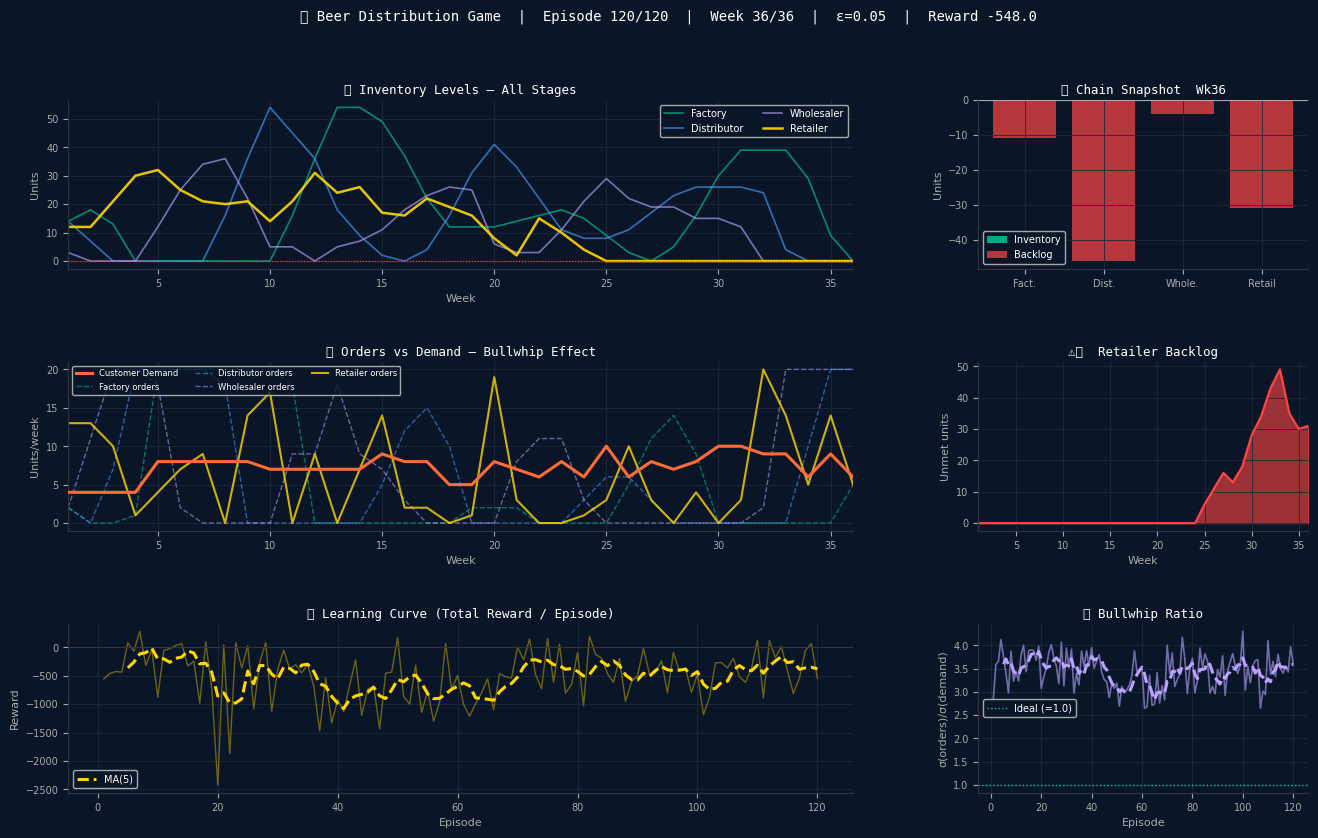


✅ Training complete!


In [9]:
# CELL 9 — TRAINING with live animation
#
# Each episode = 36 weeks of the Beer Game.
# You watch the supply chain play out week by week.
# 6 live panels update simultaneously.
# ─────────────────────────────────────────────────────────
print(f'Training: {N_EPISODES} episodes × {N_WEEKS} weeks each\n')

agent         = BeerAgent()
reward_hist   = []
bullwhip_hist = []

for ep in range(N_EPISODES):
    # Run episode with frame collection
    total_r, env, frames = agent.run_episode(ep, render=True)
    reward_hist.append(agent.memory.rewards[-1])
    bullwhip_hist.append(agent.memory.bullwhip_ratios[-1])

    # Render selected frames
    render_weeks = [f for i, f in enumerate(frames)
                    if i % RENDER_EVERY == 0 or f['done']]

    for f in render_weeks:
        png = make_beer_frame(
            week            = f['week'],
            inv_hist        = f['inv'],
            order_hist      = f['orders'],
            backlog_hist    = f['backlog'],
            demand_hist     = f['demand'],
            ep_num          = ep,
            total_reward    = f['reward'],
            epsilon         = agent.epsilon,
            reward_history  = reward_hist,
            bullwhip_history= bullwhip_hist,
        )
        clear_output(wait=True)
        display(IPImage(data=png))
        time.sleep(EPISODE_SLEEP if f['done'] else WEEK_SLEEP)

print('\n✅ Training complete!')

In [10]:
# CELL 10 — Memory analysis: what did the agent learn?
mem   = agent.memory
early = mem.episodes[:15]
late  = mem.episodes[-15:]

print('='*65)
print('  AGENT MEMORY ANALYSIS')
print('='*65)

for label, group in [('First 15 episodes (untrained)', early),
                      ('Last  15 episodes (trained)',   late)]:
    print(f'\n{label}:')
    print(f'  avg reward        : {np.mean([e["reward"]   for e in group]):>9.2f}')
    print(f'  avg total backlog : {np.mean([e["backlog"]  for e in group]):>9.1f}  units')
    print(f'  avg holding cost  : {np.mean([e["holding"]  for e in group]):>9.1f}  units×weeks')
    print(f'  avg bullwhip ratio: {np.mean([e["bullwhip"] for e in group]):>9.3f}  (ideal=1.0)')
    print(f'  avg stockout weeks: {np.mean([e["stockouts"]for e in group]):>9.2f}  / {N_WEEKS}')

print(f'\n🏆 Best episode reward : {mem.best_reward:.2f}')

print('\n--- vs Human Baseline ---')
print(f'  Human avg reward       : {np.mean(human_rewards):>9.2f}')
print(f'  Agent avg reward (last): {np.mean([e["reward"] for e in late]):>9.2f}')
print(f'  Human avg bullwhip     : {np.mean(human_bullwhip):>9.3f}')
print(f'  Agent avg bullwhip(last): {np.mean([e["bullwhip"] for e in late]):>9.3f}')
print(f'  Human avg backlog      : {np.mean(human_backlog):>9.1f}')
print(f'  Agent avg backlog(last): {np.mean([e["backlog"] for e in late]):>9.1f}')

  AGENT MEMORY ANALYSIS

First 15 episodes (untrained):
  avg reward        :   -206.63
  avg total backlog :      51.7  units
  avg holding cost  :    1159.3  units×weeks
  avg bullwhip ratio:     3.551  (ideal=1.0)
  avg stockout weeks:      3.93  / 36

Last  15 episodes (trained):
  avg reward        :   -318.81
  avg total backlog :     143.2  units
  avg holding cost  :     869.7  units×weeks
  avg bullwhip ratio:     3.469  (ideal=1.0)
  avg stockout weeks:      8.27  / 36

🏆 Best episode reward : 284.32

--- vs Human Baseline ---
  Human avg reward       :    337.78
  Agent avg reward (last):   -318.81
  Human avg bullwhip     :     1.153
  Agent avg bullwhip(last):     3.469
  Human avg backlog      :       0.0
  Agent avg backlog(last):     143.2


In [11]:
# CELL 11 — Full evaluation dashboard
ep_x = list(range(1, N_EPISODES+1))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor(C_BG)
fig.suptitle('🍺 Beer Game RL Agent — Full Evaluation Dashboard',
             color='white', fontsize=14, fontfamily='monospace', y=1.01)

def sax(ax, title, xl, yl):
    ax.set_facecolor(C_BG)
    ax.set_title(title, color='white', fontsize=10, fontfamily='monospace')
    ax.set_xlabel(xl, color='#aaa', fontsize=9)
    ax.set_ylabel(yl, color='#aaa', fontsize=9)
    ax.tick_params(colors='#aaa')
    for sp in ['top','right']: ax.spines[sp].set_visible(False)
    ax.spines['bottom'].set_color('#334')
    ax.spines['left'].set_color('#334')
    ax.grid(True, color=C_GRID, linewidth=0.7)

# 1 — Reward
ax = axes[0][0]
ax.plot(ep_x, mem.rewards, color=C_RETAIL, alpha=0.4, linewidth=1)
ax.plot(ep_x, pd.Series(mem.rewards).rolling(8).mean(),
        color=C_RETAIL, linewidth=2.5, label='MA(8)')
ax.axhline(np.mean(human_rewards), color=C_DEMAND, linewidth=1.5,
           linestyle='--', label=f'Human avg ({np.mean(human_rewards):.0f})')
ax.fill_between(ep_x, mem.rewards, alpha=0.07, color=C_RETAIL)
sax(ax, '🏆 Total Reward / Episode', 'Episode', 'Reward')
ax.legend(facecolor=C_BG, labelcolor='white', fontsize=8)

# 2 — Bullwhip ratio
ax = axes[0][1]
ax.plot(ep_x, mem.bullwhip_ratios, color='#b8a4ff', alpha=0.4, linewidth=1)
ax.plot(ep_x, pd.Series(mem.bullwhip_ratios).rolling(8).mean(),
        color='#b8a4ff', linewidth=2.5, label='MA(8)')
ax.axhline(1.0, color='#00c896', linewidth=1.5,
           linestyle=':', label='Ideal = 1.0')
ax.axhline(np.mean(human_bullwhip), color=C_DEMAND, linewidth=1.5,
           linestyle='--', label=f'Human ({np.mean(human_bullwhip):.2f})')
sax(ax, '🌊 Bullwhip Ratio (lower=better)', 'Episode', 'σ(orders)/σ(demand)')
ax.legend(facecolor=C_BG, labelcolor='white', fontsize=8)

# 3 — Total backlog
ax = axes[0][2]
ax.plot(ep_x, mem.total_backlogs, color=C_BACKLOG, alpha=0.4, linewidth=1)
ax.plot(ep_x, pd.Series(mem.total_backlogs).rolling(8).mean(),
        color=C_BACKLOG, linewidth=2.5, label='MA(8)')
ax.axhline(np.mean(human_backlog), color=C_DEMAND, linewidth=1.5,
           linestyle='--', label=f'Human ({np.mean(human_backlog):.0f})')
sax(ax, '⚠️  Total Backlog / Episode', 'Episode', 'Unmet demand (units)')
ax.legend(facecolor=C_BG, labelcolor='white', fontsize=8)

# 4 — Stockout weeks
ax = axes[1][0]
ax.bar(ep_x, mem.stockout_weeks,
       color=[C_BACKLOG if s>0 else '#00c896' for s in mem.stockout_weeks],
       alpha=0.75, width=0.8)
sax(ax, '🚫 Stockout Weeks / Episode', 'Episode', 'Weeks with stockout')

# 5 — Agent vs Human comparison bar
ax = axes[1][1]
metrics      = ['Reward', 'Bullwhip', 'Backlog', 'Stockouts']
human_vals   = [np.mean(human_rewards), np.mean(human_bullwhip),
                np.mean(human_backlog), 0]  # stockouts not tracked for human
agent_late   = [np.mean([e['reward']   for e in late]),
                np.mean([e['bullwhip'] for e in late]),
                np.mean([e['backlog']  for e in late]),
                np.mean([e['stockouts']for e in late])]
x = np.arange(4); w = 0.35
ax.bar(x-w/2, human_vals,  w, label='Human baseline', color=C_DEMAND, alpha=0.8)
ax.bar(x+w/2, agent_late,  w, label='RL Agent (last 15)', color='#00c896', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(metrics, color='#aaa', fontsize=9)
sax(ax, '📊 Agent vs Human (last 15 eps)', '', 'Value')
ax.legend(facecolor=C_BG, labelcolor='white', fontsize=8)

# 6 — Best episode orders vs demand
ax = axes[1][2]
if mem.best_orders:
    wks = list(range(1, len(mem.best_orders)+1))
    best_env = BeerGameEnv(demand_seed=0)
    best_env.reset()
    ax.plot(wks, generate_demand(len(mem.best_orders)),
            color=C_DEMAND, linewidth=2, label='Customer demand')
    ax.plot(wks, mem.best_orders,
            color=C_RETAIL, linewidth=2, label=f'Agent orders (best ep)')
    ax.fill_between(wks, generate_demand(len(mem.best_orders)),
                    mem.best_orders, alpha=0.1, color='white')
sax(ax, f'🏆 Best Episode: Orders vs Demand', 'Week', 'Units')
ax.legend(facecolor=C_BG, labelcolor='white', fontsize=8)

plt.tight_layout()
plt.savefig('beer_game_evaluation.png', dpi=150,
            bbox_inches='tight', facecolor=C_BG)
plt.show()
print('Saved: beer_game_evaluation.png')

/tmp/ipykernel_9591/4260670792.py:91: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_9591/4260670792.py:91: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_9591/4260670792.py:91: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_9591/4260670792.py:91: UserWarning: Glyph 128683 (\N{NO ENTRY SIGN}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_9591/4260670792.py:91: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_9591/4260670792.py:91: UserWarning: Glyph 127866 (\N{BEER MUG}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_9591/4260670792.py:92: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('beer_game_evaluat

Saved: beer_game_evaluation.png


In [12]:
# CELL 12 — Memory table
df = pd.DataFrame(mem.episodes)
df['reward_ma5']   = df['reward'].rolling(5).mean().round(2)
df['bullwhip_ma5'] = df['bullwhip'].rolling(5).mean().round(3)
print('Agent Memory Table — first 15 + last 15 episodes')
display(pd.concat([df.head(15), df.tail(15)]).drop_duplicates().style
    .background_gradient(subset=['reward'],   cmap='RdYlGn')
    .background_gradient(subset=['backlog'],  cmap='RdYlGn_r')
    .background_gradient(subset=['bullwhip'], cmap='RdYlGn_r')
    .background_gradient(subset=['stockouts'],cmap='RdYlGn_r')
    .format({'reward':'{:.2f}','bullwhip':'{:.3f}','reward_ma5':'{:.2f}'}))

Agent Memory Table — first 15 + last 15 episodes


,episode,reward,backlog,holding,bullwhip,stockouts,reward_ma5,bullwhip_ma5
0,0,-555.53,0,2323,2.854,0,nan,nan
1,1,-457.84,0,2014,3.589,0,nan,nan
2,2,-424.00,0,2108,3.654,0,nan,nan
3,3,-433.92,0,1958,4.125,0,nan,nan
4,4,82.65,53,341,3.767,9,-357.73,3.598000
5,5,-66.54,0,1324,3.404,0,-259.93,3.708000
6,6,284.32,3,462,2.980,2,-111.50,3.586000
7,7,-319.88,0,1724,3.874,0,-90.67,3.630000
8,8,-37.30,98,551,3.229,8,-11.35,3.451000
9,9,-877.39,435,518,3.436,15,-203.36,3.385000


In [13]:
# CELL 13 — KPI Summary Report
print('='*65)
print('  KPI SUMMARY — Beer Distribution Game RL Agent')
print('='*65)
print(f'''
Simulation:
  Episodes    : {N_EPISODES}
  Weeks/ep    : {N_WEEKS}
  Lead time   : {LEAD_TIME} weeks
  Action space: 0–{MAX_ORDER} units/order

                     Human baseline    Agent (last 15)
  Avg Reward       : {np.mean(human_rewards):>10.2f}    {np.mean([e["reward"] for e in late]):>10.2f}
  Avg Bullwhip     : {np.mean(human_bullwhip):>10.3f}    {np.mean([e["bullwhip"] for e in late]):>10.3f}
  Avg Backlog      : {np.mean(human_backlog):>10.1f}    {np.mean([e["backlog"] for e in late]):>10.1f}
  Avg Stockout wks : {'N/A':>10}    {np.mean([e["stockouts"] for e in late]):>10.2f}

  Best episode reward : {mem.best_reward:.2f}

Bullwhip Effect:
  Ratio > 1 means agent amplifies demand variance (bad)
  Ratio = 1 means agent passes demand through unchanged (ideal)
  Ratio < 1 means agent dampens variance (excellent)
  Agent final ratio: {np.mean([e["bullwhip"] for e in late]):.3f}
''')
print('='*65)
print('Saved: beer_game_evaluation.png')

  KPI SUMMARY — Beer Distribution Game RL Agent

Simulation:
  Episodes    : 120
  Weeks/ep    : 36
  Lead time   : 2 weeks
  Action space: 0–20 units/order

                     Human baseline    Agent (last 15)
  Avg Reward       :     337.78       -318.81
  Avg Bullwhip     :      1.153         3.469
  Avg Backlog      :        0.0         143.2
  Avg Stockout wks :        N/A          8.27

  Best episode reward : 284.32

Bullwhip Effect:
  Ratio > 1 means agent amplifies demand variance (bad)
  Ratio = 1 means agent passes demand through unchanged (ideal)
  Ratio < 1 means agent dampens variance (excellent)
  Agent final ratio: 3.469

Saved: beer_game_evaluation.png
